# STEP 3 · 年度策略与真实新增对照

固定需求面，逐年用 `station_snapshot(Y)` 的存量做 baseline + S1/S2/S3，并与 `Y+1` 真实新增对照。

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cso, style
style.set_nature()

CITY = 'guangzhou'
CITY_CONFIG = ''
MODE = 'truncated'
NOTEBOOK_SMOKE = True     # True=少抽样/少天数/小候选，先快速跑通链路

cso.configure_city(CITY, CITY_CONFIG or None)
DRAWS = 5 if NOTEBOOK_SMOKE else cso.N_ENSEMBLE
OUT = cso.OUTPUT_ROOT / cso.CITY / 'notebook_step3'
OUT.mkdir(parents=True, exist_ok=True)
print(f'城市 {cso.CITY_NAME}({cso.CITY}) | 口径 {MODE} | 抽样 {DRAWS} | 发现 {len(cso.DAYS)} 天')
print('比例 S1:', cso.ADD_FRACS, '| S2:', cso.REMOVE_FRACS, '| S3:', cso.SWAP_FRACS)
print('图件输出目录:', OUT)

城市 广州(guangzhou) | 口径 truncated | 抽样 5 | 发现 7 天
比例 S1: (0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5) | S2: (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9) | S3: (0.01, 0.05, 0.1, 0.2, 0.3)
图件输出目录: D:\Desktop\香港大学\20260521 根据网约车轨迹优化充电站\ChargingStationOptimization\Outputs\guangzhou\notebook_step3


## 3.1 固定需求面

In [2]:
D = cso.build_demand_surface(draws=DRAWS)
w = D['w']
years = cso.station_years()
cum = {Y: len(cso.station_snapshot(Y)) for Y in years}
print('需求节点', D['n_cells'], '| 事件合计', f"{w.sum():.0f}", '| 年份', years)
print('逐年累计存量:', cum)

[OSMnx] 载入缓存路网图 _graph_guangzhou.graphml ...
[OSMnx] 路网图就绪：75,488 节点，166,968 边


需求面·7天×5抽样(路网节点中心):   0%|          | 0/7 [00:00<?, ?it/s]

需求节点 25940 | 事件合计 4595 | 年份 [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
逐年累计存量: {2017: 88, 2018: 663, 2019: 938, 2020: 1077, 2021: 1586, 2022: 1946, 2023: 2408, 2024: 2749}


## 3.2 每年 baseline + 指定年份 S1/S2/S3
`run_scenarios=False` 先只算各年 baseline；策略对 `STRATEGY_YEARS` 指定年份运行，由 `RUN_S1/RUN_S2/RUN_S3` 开关控制。

In [3]:
res = cso.run_yearly_scenarios(years=years, demand=D, smoke=NOTEBOOK_SMOKE,
                               run_scenarios=False)

# 运行控制：默认只跑 S1；需要 S2/S3 时把对应开关改为 True。
STRATEGY_YEARS = [years[-2] if len(years) > 1 else years[-1]]
RUN_S1 = True
RUN_S2 = False
RUN_S3 = False

# S1_BACKEND='dense' 不预分配 需求点×(现有站+新增站) 的超大矩阵，适合 notebook 全比例运行；
# 如果你确认内存充足，可改成 'fast' 以换取速度。
S1_BACKEND = 'fast'
S3_BACKEND = 'fast'

# 默认使用全局比例；CAND_CAP/CAP_POOL 会按最大目标数动态抬高，不再截断 ADD_FRACS=0.5 这类规模。
S1_FRACS = cso.ADD_FRACS
S2_FRACS = cso.REMOVE_FRACS
S3_FRACS = cso.SWAP_FRACS

def _max_count_for(year_list, fracs):
    vals = []
    for yy in year_list:
        vals.extend(cso.counts_from_fracs(len(res[yy]['stations']), fracs))
    return int(max(vals)) if vals else 0

candidate_target = max(
    _max_count_for(STRATEGY_YEARS, S1_FRACS) if RUN_S1 else 0,
    _max_count_for(STRATEGY_YEARS, S3_FRACS) if RUN_S3 else 0,
)
CANDIDATE_CAP = max(80 if NOTEBOOK_SMOKE else cso.CAND_CAP, candidate_target)
GREEDY_POOL_N = max(20 if NOTEBOOK_SMOKE else cso.CAP_POOL, candidate_target)

need_candidates = RUN_S1 or RUN_S3
if need_candidates:
    clon, clat = cso._candidates_from_demand(D, cap=CANDIDATE_CAP, smoke=NOTEBOOK_SMOKE)
    print(f"候选新增点 {len(clon)} 个；CELF候选池上限 {GREEDY_POOL_N}；最大策略目标 {candidate_target}")

for Y in STRATEGY_YEARS:
    r = res[Y]
    stY = r['stations']
    slonY, slatY = stY['lon'].to_numpy(), stY['lat'].to_numpy()
    fastY, slowY = stY['fast'].to_numpy(), stY['slow'].to_numpy()
    active = [name for name, flag in [('S1', RUN_S1), ('S2', RUN_S2), ('S3', RUN_S3)] if flag]
    print(f"[{Y}] 运行策略: {active if active else '无'}")
    if not active:
        continue
    cY = cso.dist_matrix(D['lon_c'], D['lat_c'], slonY, slatY)
    if RUN_S1:
        r['s1'] = cso.run_s1_add(w, cY, fastY, slowY, clon, clat, D['lon_c'], D['lat_c'],
                                 fracs=S1_FRACS, s=r['s_fix'], d_ref=r['d_ref'],
                                 pool_n=GREEDY_POOL_N, backend=S1_BACKEND)
    if RUN_S2:
        r['s2'] = cso.run_s2_remove(w, cY, fastY, slowY, fracs=S2_FRACS,
                                    s=r['s_fix'], d_ref=r['d_ref'])
    if RUN_S3:
        r['s3'] = cso.run_s3_swap(w, cY, fastY, slowY, clon, clat, D['lon_c'], D['lat_c'],
                                  fracs=S3_FRACS, s=r['s_fix'], d_ref=r['d_ref'],
                                  pool_n=GREEDY_POOL_N, backend=S3_BACKEND)

base_rows = []
for Y, r in res.items():
    b = r['baseline']
    base_rows.append(dict(年份=Y, 站点=len(r['stations']), M=round(b['M'],0),
                          M_access=round(b['M_access'],0), M_crowd=round(b['M_crowd'],0),
                          M_reach=round(b['M_reach'],0), 可达覆盖率=round(b['reach_cov'],3),
                          超容量站=b['over_cap'],
                          已跑策略=','.join(k.upper() for k in ('s1','s2','s3') if k in r)))
display(pd.DataFrame(base_rows))

[路网] 把 25940 需求点 + 88 站点 snap 到路网节点...


scipy最短路·81个站点节点(cutoff 100km):   0%|          | 0/2 [00:00<?, ?it/s]

[2017] 存量 88 | M=134069 (acc63302+crowd15510+reach55257) | 可达覆盖 0.988
[路网] 把 25940 需求点 + 663 站点 snap 到路网节点...


scipy最短路·556个站点节点(cutoff 100km):   0%|          | 0/9 [00:00<?, ?it/s]

[2018] 存量 663 | M=114593 (acc54186+crowd5150+reach55257) | 可达覆盖 0.988
[路网] 把 25940 需求点 + 938 站点 snap 到路网节点...


...

scipy最短路·1849个站点节点(cutoff 100km):   0%|          | 0/29 [00:00<?, ?it/s]

[路网] 把 25940 需求点 + 1204 站点 snap 到路网节点...


scipy最短路·1204个站点节点(cutoff 100km):   0%|          | 0/19 [00:00<?, ?it/s]

S1 只增:   0%|          | 0/1204 [00:00<?, ?it/s]

,年份,站点,M,M_access,M_crowd,M_reach,可达覆盖率,超容量站,已跑策略
0,2017,88,134069.0,63302.0,15510.0,55257.0,0.988,31,
1,2018,663,114593.0,54186.0,5150.0,55257.0,0.988,231,
2,2019,938,116328.0,55657.0,5414.0,55257.0,0.988,282,
3,2020,1077,114790.0,56329.0,5347.0,53114.0,0.988,323,
4,2021,1586,109245.0,52490.0,3812.0,52943.0,0.988,530,
5,2022,1946,106091.0,51792.0,3270.0,51029.0,0.989,649,
6,2023,2408,105181.0,51360.0,2793.0,51029.0,0.989,879,S1
7,2024,2749,105139.0,51523.0,2588.0,51029.0,0.989,959,


## 3.3 各年情景降幅曲线：总 M 与三项分解（access / crowd / reach）
每个年份单独一行、每个策略一列；每张子图同时画 `M/M_base` 与 `M_access/M_access_base`、`M_crowd/M_crowd_base`、`M_reach/M_reach_base`，并在各**比例节点（站点变化 %）**于总 M 曲线上打点标注 比例% 与 总 M 降幅 ↓%。

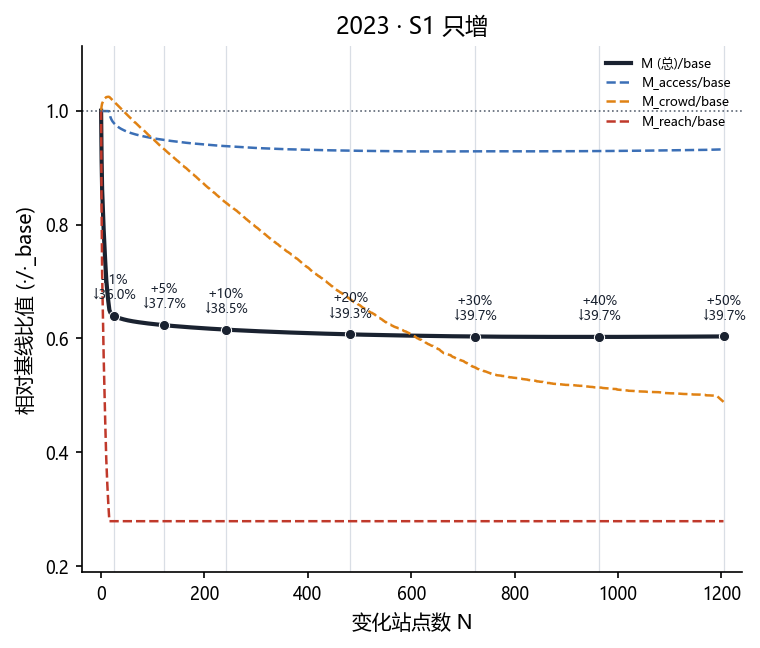

In [4]:
# 各年 × 各策略：总 M/M_base 与三项分解(access/crowd/reach)各自相对基线的降幅；
# 并在各比例节点(站点变化%)于【总 M 曲线】上打点标注 比例% 与 总M降幅↓%。
# 不同年份分行（每行一个年份），不把不同年份混在同一张子图里。
SIGN = {'s1': '+', 's2': '-', 's3': '±'}
active = [(k, t) for k, t in [('s1', 'S1 只增'), ('s2', 'S2 只减'), ('s3', 'S3 等量调配')]
          if any(k in res[Y] for Y in STRATEGY_YEARS)]
if not active:
    print('当前没有运行任何策略；请在 3.2 cell 打开 RUN_S1/RUN_S2/RUN_S3。')
else:
    nyr = len(STRATEGY_YEARS); ncol = len(active)
    fig, axes = plt.subplots(nyr, ncol, figsize=style.mm(82 * ncol, 70 * nyr), squeeze=False)
    for ri, Y in enumerate(STRATEGY_YEARS):
        for ci, (scen, tit) in enumerate(active):
            axi = axes[ri][ci]
            if scen in res[Y]:
                rsc = res[Y][scen]
                cso.plot_scenario_decomp(axi, rsc, title=f'{Y} · {tit}',
                                         counts=rsc.get('actual_counts', rsc.get('counts')),
                                         fracs=rsc.get('fracs'), sign=SIGN.get(scen, ''))
            else:
                axi.set_axis_off()
    plt.tight_layout(); style.savefig(fig, OUT / 'fig_scenario_decomp.png'); plt.show()

## 3.4 某年变化地图：新增(绿星) / 关闭(红叉) / 真实下一年新增(紫三角)

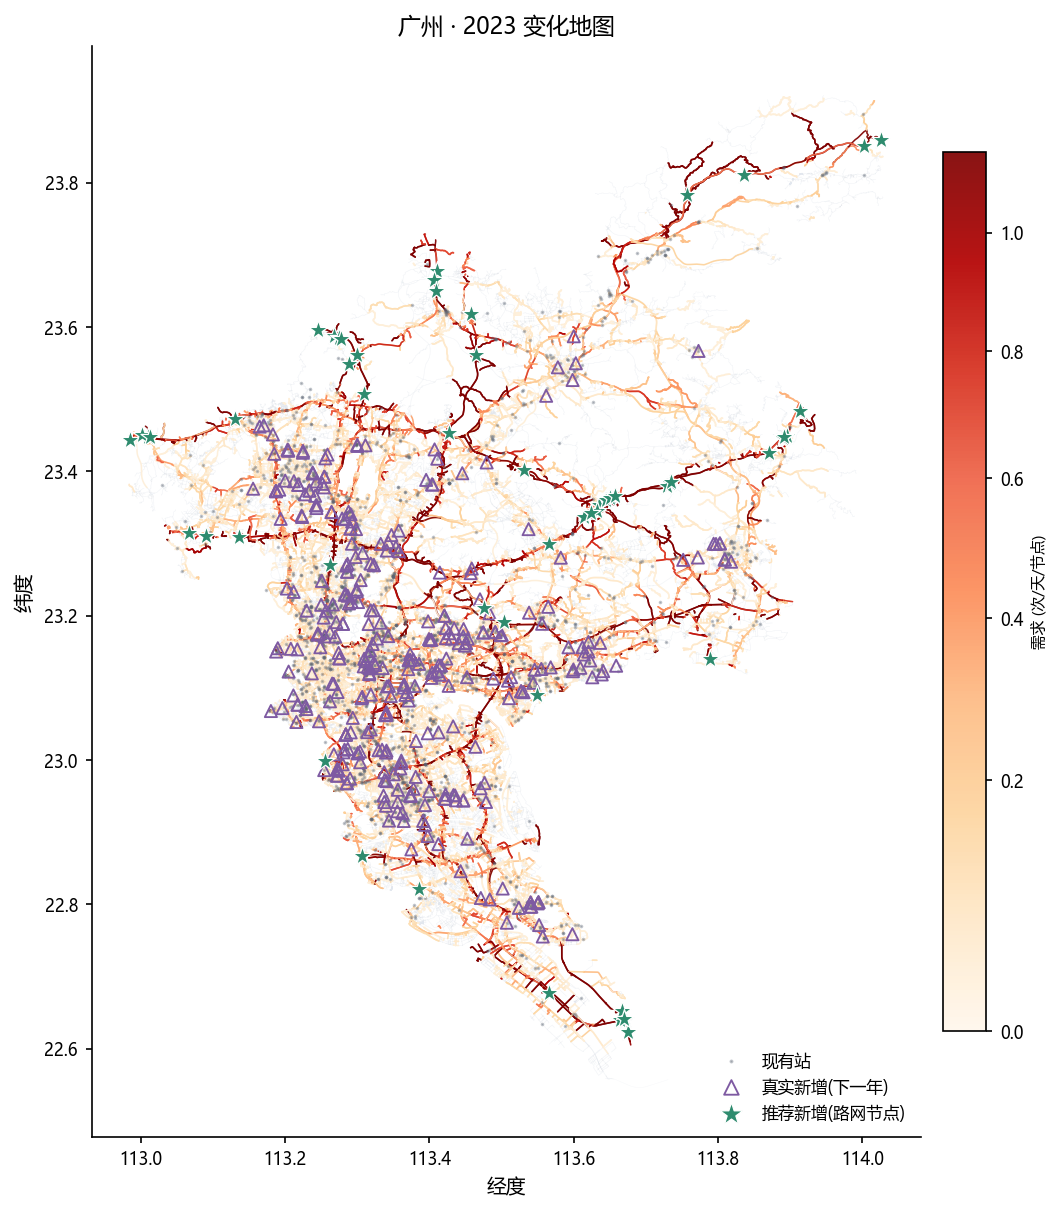

In [5]:
yrs_s = [Y for Y in STRATEGY_YEARS if 's1' in res[Y]]
if not yrs_s:
    print('当前没有 S1 结果，跳过变化地图；请在 3.2 cell 设置 RUN_S1=True。')
else:
    Y0 = yrs_s[len(yrs_s) // 2]
    st0 = res[Y0]['stations']; slon0, slat0 = st0['lon'].to_numpy(), st0['lat'].to_numpy()
    clon, clat = cso._candidates_from_demand(D, cap=CANDIDATE_CAP, smoke=NOTEBOOK_SMOKE)
    sel = np.asarray(res[Y0]['s1']['sel'], int)[:60]                    # 展示前 60 个推荐新增
    add_lon = clon[sel] if sel.size else np.array([]); add_lat = clat[sel] if sel.size else np.array([])
    rm = np.asarray(res[Y0]['s2']['order'], int)[:60] if 's2' in res[Y0] else np.array([], dtype=int)
    real = res[Y0]['real_next']
    rl = real['lon'].to_numpy() if real is not None else None
    ra = real['lat'].to_numpy() if real is not None else None
    fig, ax = plt.subplots(figsize=style.mm(150, 150))
    lc = cso.plot_change_map(ax, D, slon0, slat0, add_lon=add_lon, add_lat=add_lat, remove_idx=rm,
                             real_lon=rl, real_lat=ra, title=f'{cso.CITY_NAME} · {Y0} 变化地图')
    if lc is not None:
        fig.colorbar(lc, ax=ax, fraction=0.04, pad=0.02).set_label('需求 (次/天/节点)', fontsize=7)
    style.savefig(fig, OUT / f'fig_change_map_{Y0}.png'); plt.show()

## 3.5 推荐新增 vs 真实下一年新增 对照

,年份,真实新增,推荐数,中位最近km,命中率_1km,命中率_2km,命中率_5km
0,2023,341,341,7.72,0.021,0.056,0.252


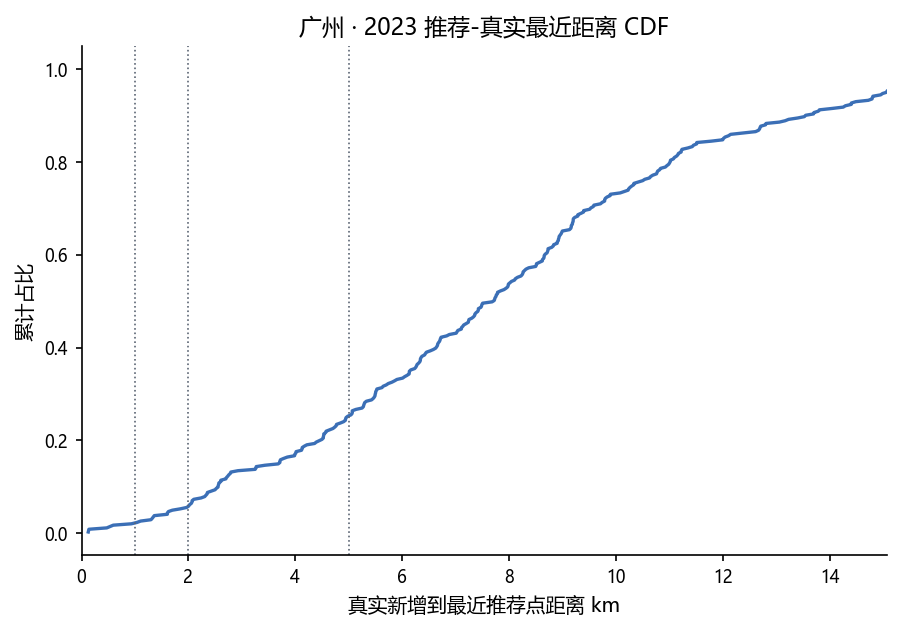

In [6]:
if 'clon' not in globals() or 'clat' not in globals():
    cap = globals().get('CANDIDATE_CAP', 80 if NOTEBOOK_SMOKE else cso.CAND_CAP)
    clon, clat = cso._candidates_from_demand(D, cap=cap, smoke=NOTEBOOK_SMOKE)

rows = []
for Y in [y for y in res if res[y]['real_next'] is not None and 's1' in res[y]]:
    real = res[Y]['real_next']; sel = np.asarray(res[Y]['s1']['sel'], int)
    K = len(real); sel_k = sel[:K]
    if sel_k.size == 0 or K == 0:
        continue
    valid = sel_k < len(clon)
    if not valid.all():
        print(f"[{Y}] 警告：有 {int((~valid).sum())} 个推荐索引超出候选数组长度，已跳过；请先重跑 3.2 cell。")
        sel_k = sel_k[valid]
    if sel_k.size == 0:
        continue
    cmp = cso.compare_recommendations_to_real(clon[sel_k], clat[sel_k],
                                              real['lon'].to_numpy(), real['lat'].to_numpy())
    hr = cmp['hit_rate']
    rows.append(dict(年份=Y, 真实新增=cmp['n_real'], 推荐数=cmp['n_rec'],
                     中位最近km=round(cmp['median_nearest'], 2),
                     命中率_1km=round(hr[1.0], 3), 命中率_2km=round(hr[2.0], 3), 命中率_5km=round(hr[5.0], 3)))
display(pd.DataFrame(rows))
if rows:
    Yc = rows[len(rows) // 2]['年份']; real = res[Yc]['real_next']
    sel = np.asarray(res[Yc]['s1']['sel'], int)[:len(real)]
    sel = sel[sel < len(clon)]
    cmp = cso.compare_recommendations_to_real(clon[sel], clat[sel], real['lon'].to_numpy(), real['lat'].to_numpy())
    d = np.sort(cmp['nearest_km'])
    fig, ax = plt.subplots(figsize=style.mm(110, 70))
    ax.plot(d, np.arange(1, len(d) + 1) / len(d), '-', color=style.C['blue'])
    for t in cso.MATCH_THRESH_KM:
        ax.axvline(t, color=style.C['gray'], ls=':', lw=0.8)
    ax.set_xlabel('真实新增到最近推荐点距离 km'); ax.set_ylabel('累计占比')
    ax.set_title(f'{cso.CITY_NAME} · {Yc} 推荐-真实最近距离 CDF'); ax.set_xlim(0, max(10, float(np.percentile(d, 95))))
    style.savefig(fig, OUT / f'fig_real_vs_rec_{Yc}.png'); plt.show()